# Iteración de Valores

En este ejercicio vamos a implementar el primer método para solucionar Procesos de Decisión de Markov (MDPs). El método a implementar es la iteración de valores.

La iteración de valores esta basada en la fórmula:

![value_iteration](./img/value_iteration.png)

Para resolver los MDPs crearemos un archivo `value_iteration.py` el cual utilizaremos para solucionar el ambiente de Gridworld.

**Task 1**
1.	Implemente la classe `ValueIteration` con cuatro atributos:
    - `mdp` que corresponde al MDP a resolver (e.g., Gridworld) 
    - `discount` que corresponde al factor de decuento a utilizar, `0.9` por defecto.
    - `iterations` que corresponde a el número de iteraciones a realizar.
    - `values` que corresponde a los valores calculados para los estados del MDP.

2. El comportamiento del agente (de iteración de valores) esta dado por los métodos:
    - `run_value_iteration` que no recibe ningún parámatetro y ejecuta el algoritmo de iteración de valores para la solución del MDP.
    - `get_value` recibe un estado y retorna el valor correspondiende para dicho estado.
    - `compute_qvalue_from_values` recibe un estado y una acción y calcula el q valor correspondiente.
    - `compute_action_from_values` que calcula la acción a tomar (como la acción con el mejor valor en `values`) para un estado dado
    - `get_action` retorna la acción a tomar dado un estado (directamente como la acción de la política, sin exploración)
    - `get_qvalue` retorna el q valor dado un estado y una acción
    - `get_policy` que retorna la acción a tomar para un estado (como `get_action`). Si el estado no tiene una acción asociada a él, retorne `None`

# Entrega

Para esta tarea debe entregar: 
- La implementación de la iteración de valores para solucionar MDPs (`value_iteration.py`).
- Un documento de análisis respondiendo a las siguientes preguntas (con screenshots de la solución y las explicaciones correspondientes del comportamiento observado).
  -	Ejecute su implementación de iteración de valores para 5, 10, 15, 20, 30, 50 iteraciones, sobre el ambiente de gridworld. ¿Cuando convergen los valores o las acciones?
  -	Ejecute su implementación sobre el ambiente del puente (i.e., Bridge) durante 10 iteraciones. ¿Qué resultado observa si codifica el valor de descuento de 0.9 a 0.1. Explique si los resultados cambian y porqué. 
  
  Recuerde que el ambiente del puente se define con la matriz de `3x7` donde las filas 1 y 3 tienen recompensa -100 entre las columnas 2 y 6. La fila 2 corresponde a el puente, con entrada en la casilla `(2,1)` y salida en la casilla `(2,7)` con recompensa 100, como se muestra en la figura

  ![bridge](./img/bridge.png)


# Solución

In [ ]:
# Importamos el archivo ValueIteration.py para usar la clase ValueIteration
from environment import Environment
from value_iteration import ValueIteration

import matplotlib.pyplot as plt

In [63]:
# Utilidades
import numpy as np
np.set_printoptions(precision=4, suppress=True)

def create_heatmap(matrix, title):
    plt.figure()
    plt.imshow(matrix, cmap="RdYlGn")
    plt.colorbar(label="Value")
    plt.axis("off")

    for x in range(matrix.shape[0]):
        for y in range(matrix.shape[1]):
            plt.text(y, x, f"{matrix[x, y]:.4f}",
                    ha="center", va="center")

    plt.title(title)
    plt.show()

## Iteración de valores en Gridworld

En este caso vamos a iterar sobre dos tableros de Gridworld. El primero es el 3x4 del ejercicio anterior y luego ejecutaremos el del ambiente Bridge. Para ambos casos, vamos a ejecutar la iteración de valores para diferentes números de iteraciones y observar el comportamiento de los valores y las acciones.

In [57]:
grid_board = [[' ', ' ', ' ',  '+1'],
         [' ', '#', ' ',  '-1'],
         ['S', ' ', ' ', ' ']]

grid_P = [[[0.1, 0.1, 0, 0.8], [0.1, 0.1, 0, 0.8], [0.1, 0.1, 0, 0.8],  [1]],
         [[0.8, 0, 0.1, 0.1], '#', [0.8, 0, 0.1, 0.1],  [-1]],
         [[0.8, 0, 0.1, 0.1], [0.1, 0.1, 0.8, 0], [0.1, 0.1, 0.8, 0], [0.1, 0.1, 0.8, 0]]]

gridworld = Environment(grid_board, grid_P)

In [59]:
bridge_board = [['#', '-100', '-100',  '-100', '-100', '-100', '#'],
         ['1', 'S', ' ', ' ', ' ', ' ', '100'],
         ['#', '-100', '-100',  '-100', '-100', '-100', '#']]

bridge_P = np.full((3, 7, 4), 0.25).tolist()
# Marcamos las posiciones prohibidas en la matriz de probabilidades
bridge_P[0][0] = '#'
bridge_P[0][6] = '#'
bridge_P[2][0] = '#'
bridge_P[2][6] = '#'

# Marcamos las posiciones de recompensa en la matriz de probabilidades
bridge_P[1][0] = [1]
bridge_P[1][6] = [100]

bridge = Environment(bridge_board, bridge_P)

Value Iteration (Simple Gridworld)


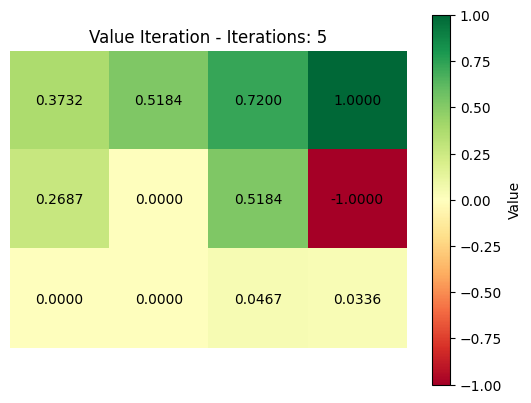

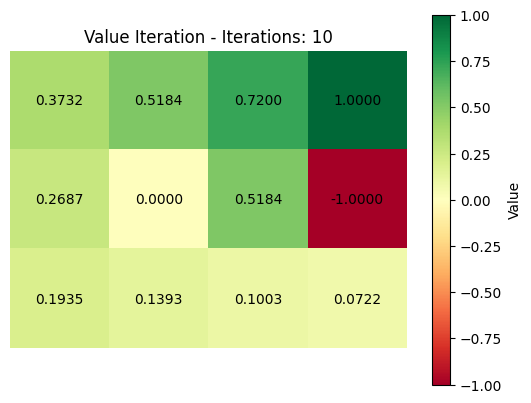

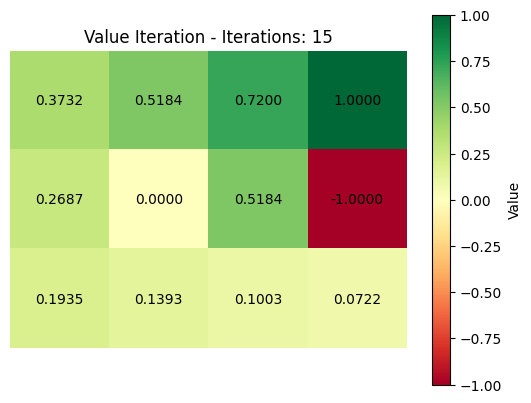

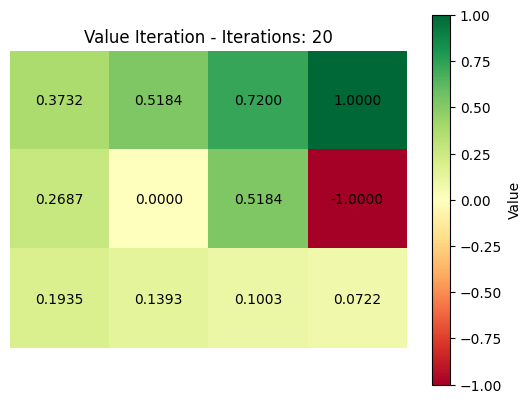

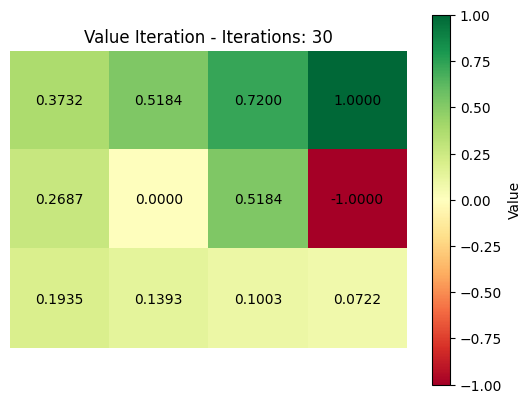

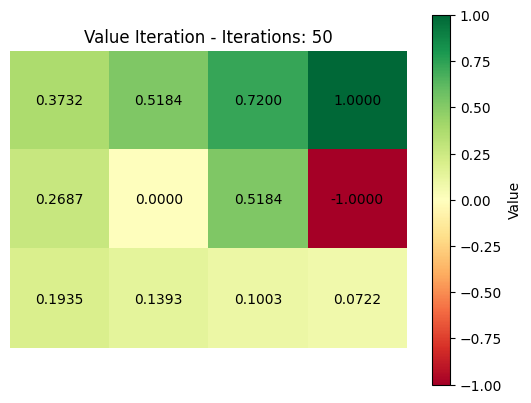

In [61]:
print("Value Iteration (Simple Gridworld)")

for i in [5, 10, 15, 20, 30, 50]:
    value_iteration = ValueIteration(gridworld, discount=0.9, iterations=i)
    value_iteration.run_value_iteration()

    matrix = np.zeros((gridworld.nrows, gridworld.ncols))

    for (x, y), value in value_iteration.values.items():
        matrix[x, y] = value
        
    create_heatmap(matrix, f"Value Iteration - Iterations: {i}")

Value Iteration (Bridge Gridworld)


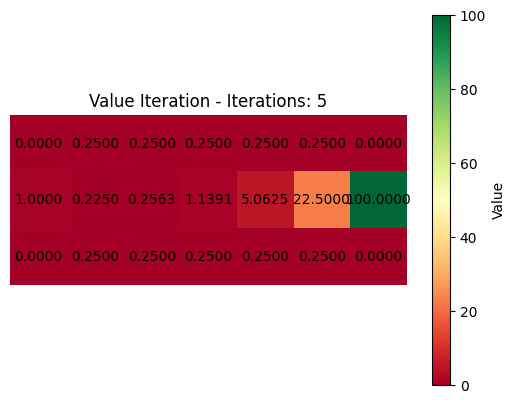

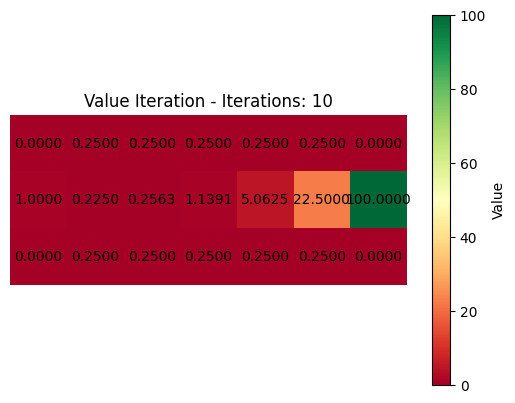

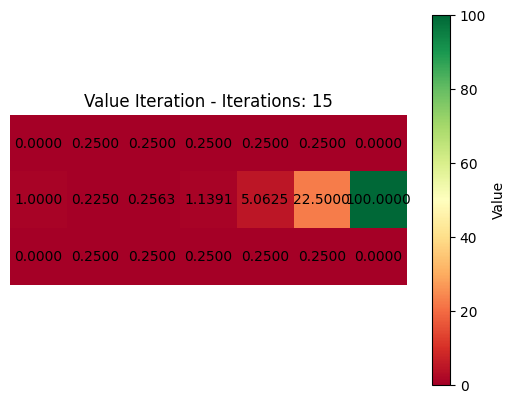

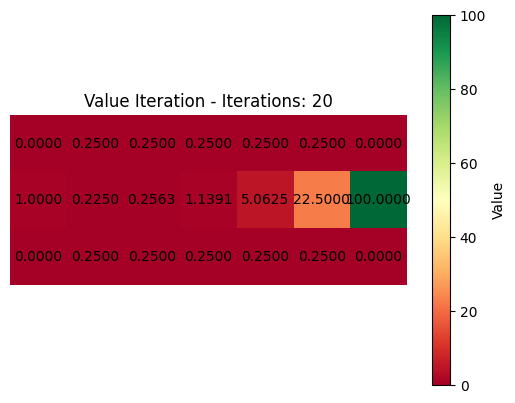

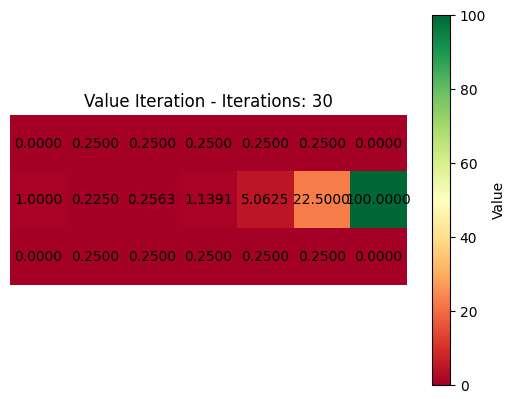

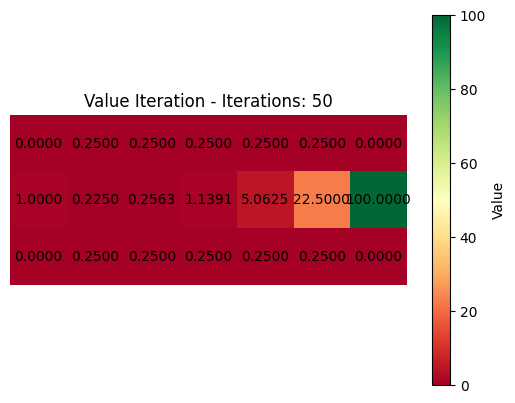

In [62]:
print("Value Iteration (Bridge Gridworld)")

for i in [5, 10, 15, 20, 30, 50]:
    value_iteration = ValueIteration(bridge, discount=0.9, iterations=i)
    value_iteration.run_value_iteration()

    matrix = np.zeros((bridge.nrows, bridge.ncols))

    for (x, y), value in value_iteration.values.items():
        matrix[x, y] = value
        
    create_heatmap(matrix, f"Value Iteration - Iterations: {i}")

Al iterar sobre el ambiente de Gridworld, podemos observar que los valores convergen bastante rápido, en la décima iteración ya los cambios no son tan significativos. En cuanto a las acciones, estas convergen incluso más rápido, en la quinta iteración ya no hay cambios en las acciones más significativas para obtener la mejor recompensa, aunque algunos estados poco comunes pueden seguir mostrando variaciones.

Cabe resaltar que como estos ambientes son pequeños, la iteración de valores converge rápidamente. En ambientes más grandes, la convergencia puede tardar más tiempo y requerir más iteraciones.

## Cambio del descuento en los ambientes de Gridworld

Discount Variation (Simple Gridworld)


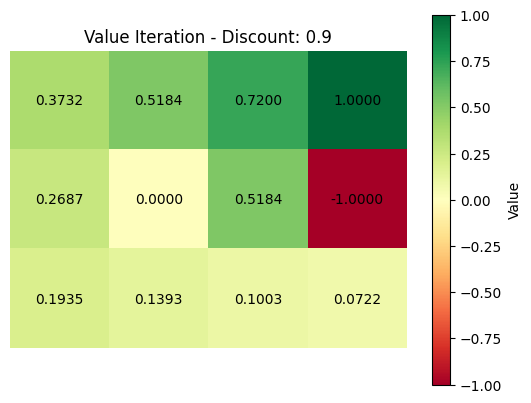

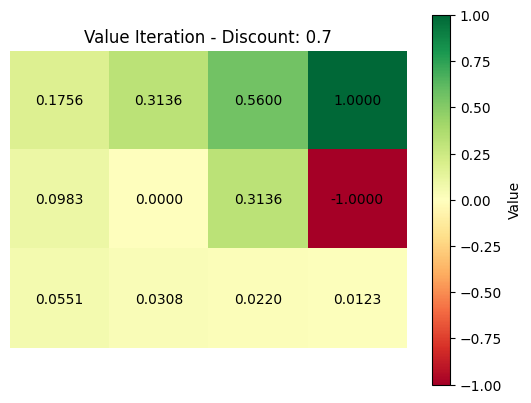

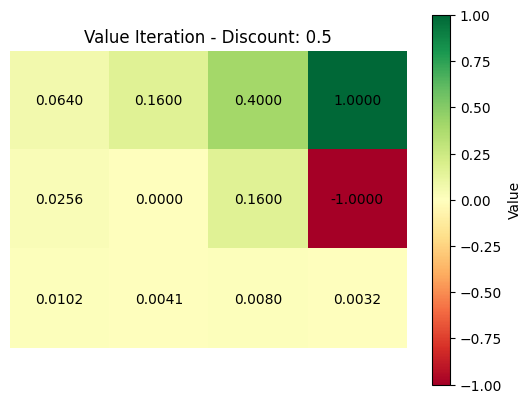

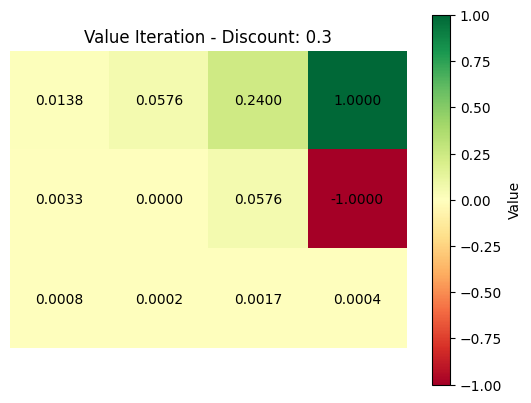

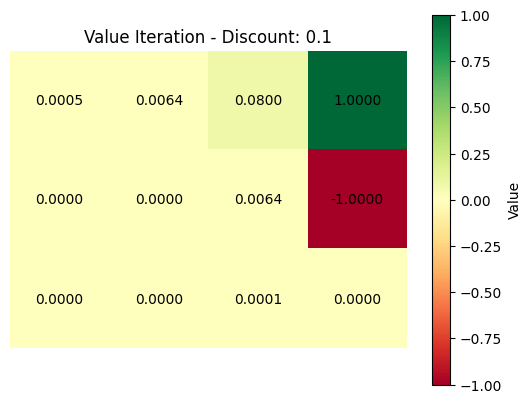

In [66]:
print("Discount Variation (Simple Gridworld)")

for discount in np.round(np.linspace(0.9, 0.1, 5), 1):
    value_iteration = ValueIteration(gridworld, discount=discount, iterations=10)
    value_iteration.run_value_iteration()

    matrix = np.zeros((gridworld.nrows, gridworld.ncols))

    for (x, y), value in value_iteration.values.items():
        matrix[x, y] = value

    create_heatmap(matrix, f"Value Iteration - Discount: {discount}")


Discount Variation (Bridge Gridworld)


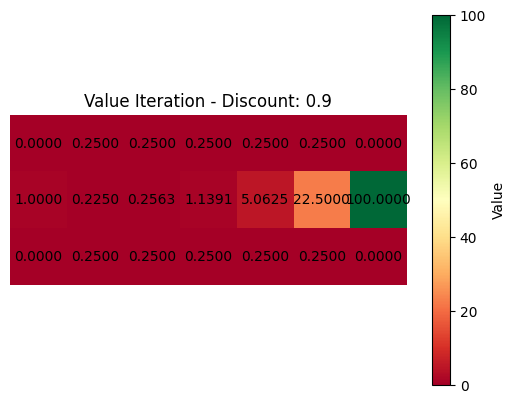

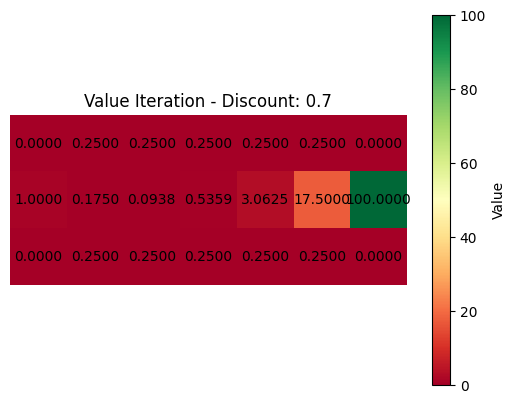

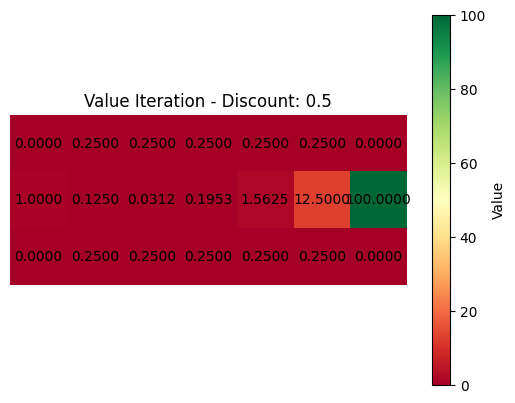

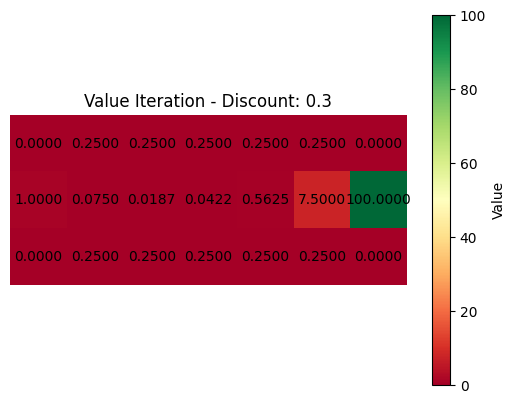

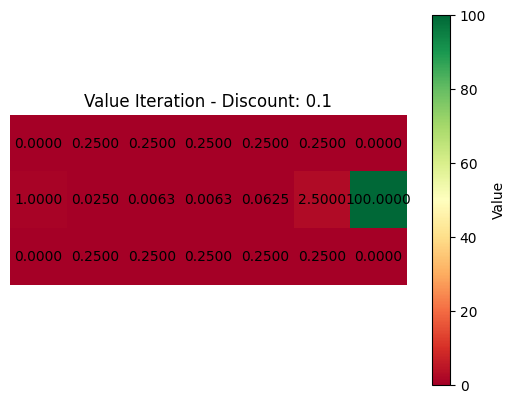

In [67]:
print("Discount Variation (Bridge Gridworld)")

for discount in np.round(np.linspace(0.9, 0.1, 5), 1):
    value_iteration = ValueIteration(bridge, discount=discount, iterations=10)
    value_iteration.run_value_iteration()

    matrix = np.zeros((bridge.nrows, bridge.ncols))

    for (x, y), value in value_iteration.values.items():
        matrix[x, y] = value

    create_heatmap(matrix, f"Value Iteration - Discount: {discount}")


Como podemos visualizar la propagación de los valores a través del ambiente se limita a un rango inferior cuando se tiene un valor de descuento muy bajo (e.g., 0.1). Esto se debe a que el agente valora mucho más las recompensas inmediatas y no le da tanta importancia a las recompensas futuras, lo que hace que los valores de los estados cercanos a las recompensas sean más altos que los estados más alejados. En cambio, con un valor de descuento alto (e.g., 0.9), el agente valora más las recompensas futuras, lo que permite una propagación más amplia de los valores a través del ambiente, resultando en valores más altos para estados más alejados de las recompensas inmediatas.

Este comportamiento se observa tanto en el ambiente de Gridworld como en el ambiente del puente, aunque en el caso del puente, la diferencia es más pronunciada debido a la presencia de recompensas negativas significativas que afectan la propagación de los valores.